# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep:18     |  |
| :-------------|:-------------|
| Meine de Boer| 6475728 |
| Hidde Petiet| 6583695 |
| Matthijs van Oostrum| 6540546 |
| Planning Groep: 18    |Tijdstip / Tijdspanne  |
|---|---|
| Sanity check/Condensator af | 13:30 |
| Gehele opdracht af | 17:00 |
| Pauze 1| 14:45-15:00 |
| Pauze 2| 16:00-16:15 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schematischefotocondensator_DEF.jpeg" alt="schets student 1" width="400"/>

In [2]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

epsilon0 = 8.854187817e-12  # F/m

def f(oppervlakte, afstand, dielektrischeConstante):
    capaciteit = (epsilon0 * dielektrischeConstante * oppervlakte) / afstand
    return capaciteit



# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [3]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren gaat zijn.


C = [f(0.01, 0.001, 3)]  # oppervlakte in m^2, afstand in m, diëlektrische constante (voor karton). Deze constante hebben wij gehaald van het internet. Volgens google lag het tussen de 2 en de 4, dus we hebben 3 genomen


print(f"Berekende capaciteit plaatcondensator groep 18 is {C[0]*1e12:.1f} pF")



Berekende capaciteit plaatcondensator groep 18 is 265.6 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
<img src="Foto-Scope-fysiekeopdracht1.jpeg" alt="schets student 1" width="400"/>
<img src="FotoFysiekeopdracht-condensatoropstelling.jpeg" alt="schets student 1" width="400"/>

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 18| 265.6 pF|1.33 V | 0.9V | 153 pF|

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
!<img src="Schetsen-mogelijke-opstellingen-opdracht2 .jpeg" alt="schets student 1" width="400"/>

In de eerste schets zien we een weegschaal. Tussen de twee condensator platen zitten een aantal veren. Als de veren in gedrukt worden, neemt de afstand tussen de platen af (d wordt kleiner). 

In de tweede foto zien we eigenlijk hetzelfde als de eerste. Echter zit in de tweede opstelling metal tussen de twee platen. Als het metaal opwarmt zet het uit. Hierdoor kan je de temperatuur berekenen. 

In de derde opstelling zitten er twee elastiekjes vast aan de bovenste plaat. Ook zit aan de bovenste plaat nog een zeil. Zodra de wind gaat waaien verandert het oppervlak A en daardoor zou je dus ook de windkracht kunnen meten. 

In de vierde opstelling zit er net gegoten beton tussen de platen. Het beton is nu dus nog vochtig en heeft dus een andere elektrische constante. Als het langzaam hard wordt, zit er minder vocht in het beton en kan je dus de verdampingssnelheid berekenen.

## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die gewicht/druk meet. (Wij gebruiken hiervoor de eerste opstelling. Wij gebruiken in plaats van veren gebruik van )

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
!<img src="Uitgewerkte_schetsDEF.jpeg" alt="schets student 1" width="400"/>

mincapaciteit is 39.788735772973844 pF
maxcapaciteit is 55.704230082163384 pF


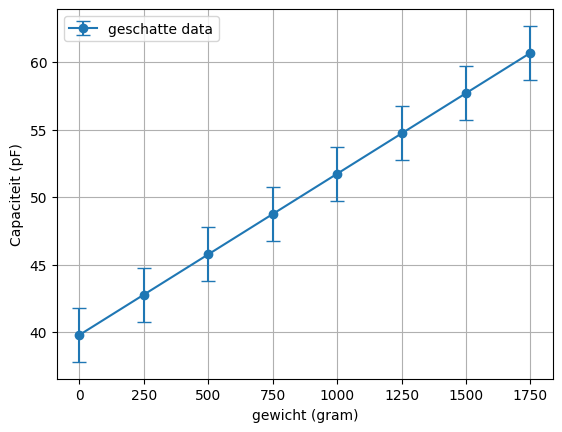

In [4]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

R=1000 #ohm. Dit is de Shunt-weerstand. 

def capaciteit(V): #Wij berekenen de capaciteit door middel van de formule V=IR+1/C*dV/dt. We hebben deze formule omgezet naar C=V/(R*1.6e6*np.pi). 
    return V/(R*1.6e6*np.pi) 


#data
gewicht  = np.array([0,250,500,750,
                 1000,1250,1500,1750]) # in gram

Volt = np.array([0.2,0.215,0.230,0.245,0.260,0.275,0.290,0.305]) #afgemeten voltage van de scope

Capaciteit = capaciteit(Volt)*1e12 #omzetten naar pF


error = np.full_like(Capaciteit, 2)  # 2 pF onzekerheid



#max en min capaciteit
mincapaciteit = capaciteit(0.200)
print("mincapaciteit is", mincapaciteit*1e12, "pF")
maxcapaciteit = capaciteit(0.280)
print("maxcapaciteit is", maxcapaciteit*1e12, "pF")

#plotten
plt.errorbar(gewicht, Capaciteit, yerr=error, marker='o', label="geschatte data", capsize=5)
plt.xlabel("gewicht (gram)")
plt.ylabel("Capaciteit (pF)")
plt.legend() 
plt.grid() 


## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 39.8 |200 mV |
| gemiddelde capaciteit| 47.7 |239 mV |
| maximale capaciteit| 55.7 |280 mV |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
!<img src="Foto_kalabratie1.jpeg" alt="schets student 1" width="400"/>
!<img src="Foto-kalabratie2.jpeg" alt="schets student 1" width="400"/>

## Opdracht 7: Plot de kalibratiegrafiek.

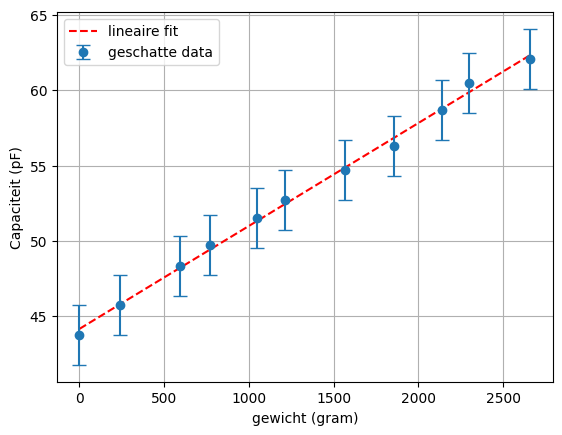

In [5]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

#zakjes gevuld met grind voor gewicht
g1 = 240.1 #gram 
g2 = 353.2 #gram
g3 = 174.8 #gram
g4 = 281.6 #gram
g5 = 161.0 #gram
g6 = 359.3 #gram
g7 = 289.2 #gram
g8 = 281.6 #gram
g9 = 161.0 #gram
g10 = 359.3 #gram


R=1000 #ohm. Dit is de Shunt-weerstand. 

def capaciteit(V): #Wij berekenen de capaciteit door middel van de formule V=IR+1/C*dV/dt. We hebben deze formule omgezet naar C=V/(R*1.6e6*np.pi). 
    return V/(R*1.6e6*np.pi) 


#data
gewicht  = np.array([0, g1, g1+g2, g1+g2+g3, g1+g2+g3+g4, g1+g2+g3+g4+g5, g1+g2+g3+g4+g5+g6, g1+g2+g3+g4+g5+g6+g7, g1+g2+g3+g4+g5+g6+g7+g8, g1+g2+g3+g4+g5+g6+g7+g8+g9, g1+g2+g3+g4+g5+g6+g7+g8+g9+g10]) # in gram

Volt = np.array([220,230,243,250,259,265,275,283,295,304,312])/1000 #afgemeten voltage van de scope

Capaciteit = capaciteit(Volt)*1e12 #omzetten naar pF

def lineair(x, a, b):
    return a * x + b

params, covariance = curve_fit(lineair, gewicht, Capaciteit)


xfit = np.linspace(np.min(gewicht), np.max(gewicht), 100)
yfit = lineair(xfit, *params)


error = np.full_like(Capaciteit, 2)  # 2 pF onzekerheid

#plotten
plt.plot(xfit, yfit, label="lineaire fit", color="red", linestyle="--")
plt.errorbar(gewicht, Capaciteit, yerr=error, fmt='o', label="geschatte data", capsize=5)
plt.xlabel("gewicht (gram)")
plt.ylabel("Capaciteit (pF)")
plt.legend() 
plt.grid() 



## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* oxidatie wegschuren met schuurpapier
* Tape aan de onderkant van het bakje, zodat het gewicht gelijker is verdeelt (het bakje het voorheen pootjes maar nu rust dus op de ducttape)

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
!<img src="Eindopstelling.jpeg" alt="schets student 1" width="400"/>

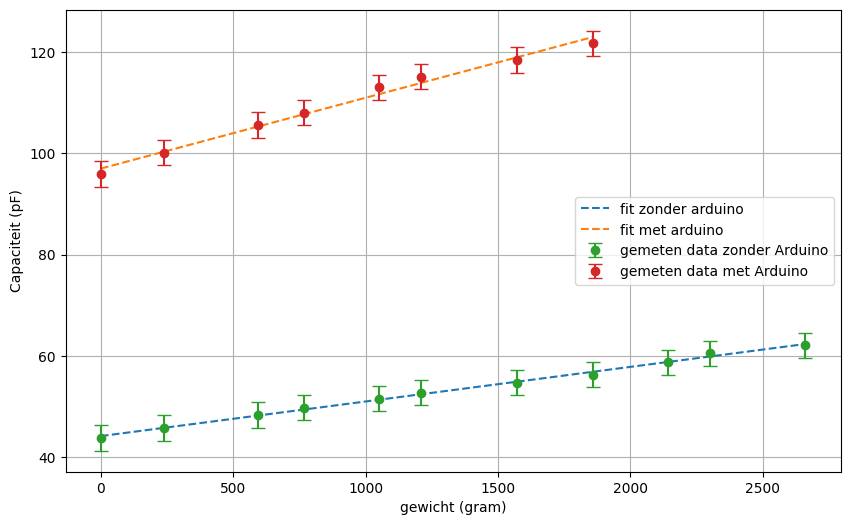

In [6]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

g1 = 240.1 #gram 
g2 = 353.2 #gram
g3 = 174.8 #gram    
g4 = 281.6 #gram
g5 = 161.0 #gram
g6 = 359.3 #gram
g7 = 289.2 #gram


R=1000 #ohm. Dit is de Shunt-weerstand. 

def capaciteit(V): #Wij berekenen de capaciteit door middel van de formule V=IR+1/C*dV/dt. We hebben deze formule omgezet naar C=V/(R*1.6e6*np.pi). 
    return V/(R*1.6e6*np.pi) 


#data
gewicht_arduino  = np.array([0, g1, g1+g2, g1+g2+g3, g1+g2+g3+g4, g1+g2+g3+g4+g5, g1+g2+g3+g4+g5+g6, g1+g2+g3+g4+g5+g6+g7]) # in gram

capaciteit_arduino = np.array([95.9, 100.1, 105.6, 108, 113, 115.1, 118.4, 121.7]) #afgemeten voltage van de scope

def lineair_arduino(x, a, b):
    return a * x + b

params_arduino, covariance_arduino = curve_fit(lineair_arduino, gewicht_arduino, capaciteit_arduino)

xfit_arduino = np.linspace(np.min(gewicht_arduino), np.max(gewicht_arduino), 100)
yfit_arduino = lineair_arduino(xfit_arduino, *params_arduino)

error_zonder = np.full_like(Capaciteit, 2.5)          # ±2.5 pF fout
error_met = np.full_like(capaciteit_arduino, 2.5)     # ±2.5 pF fout

#plotten
plt.figure(figsize=(10,6))
plt.plot(xfit, yfit, label="fit zonder arduino", linestyle="--")
plt.plot(xfit_arduino, yfit_arduino, label="fit met arduino", linestyle="--")
plt.errorbar(gewicht, Capaciteit, yerr=error_zonder, fmt='o', capsize=5,
             label="gemeten data zonder Arduino")

plt.errorbar(gewicht_arduino, capaciteit_arduino, yerr=error_met, fmt='o', capsize=5,
             label="gemeten data met Arduino")
plt.xlabel("gewicht (gram)")
plt.ylabel("Capaciteit (pF)")
plt.legend() 
plt.grid() 



## Opdracht 10: Vul hieronder de conclusie in.

Al is de sensor niet de handigste of meest ideale weegschaal, doet hij wel wat ervan word verwacht. Het meet correct het gewicht dat er op wordt geplaatst, en laat op deze schaal een lineair verband zien. Dit is precies zoals wij dit hadden voorspeld in de ontwerpgrafiek. Opvallend is dat de fit van het lineare verband met de arduino wat stijler is dan die van het lineare verband met de oscilloscoop. Dit kan worden verklaard doordat de weerstanden bij de arduino een andere grootte hebben dan bij de oscilloscoop, waar een shuntweerstand wordt gebruikt. De iteratie die wij hebben ingevoerd heeft zeker een verbetering gebracht. Te zien was dat de capaciteit zonder de oxidatie weg te schuren heel erg schommelde en deze ook lager was dan verwacht. Deze problemen waren meteen opgelost na het schuren van de platen. 

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schematischefotocondensator_DEF.jpeg" alt="schets student 1" width="400"/>

In [7]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

epsilon0 = 8.854187817e-12  # F/m

def f(oppervlakte, afstand, dielektrischeConstante):
    capaciteit = (epsilon0 * dielektrischeConstante * oppervlakte) / afstand
    return capaciteit



# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [8]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren gaat zijn.


C = [f(0.01, 0.001, 3)]  # oppervlakte in m^2, afstand in m, diëlektrische constante (voor karton). Deze constante hebben wij gehaald van het internet. Volgens google lag het tussen de 2 en de 4, dus we hebben 3 genomen


print(f"Berekende capaciteit plaatcondensator groep 18 is {C[0]*1e12:.1f} pF")



Berekende capaciteit plaatcondensator groep 18 is 265.6 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
<img src="Foto-Scope-fysiekeopdracht1.jpeg" alt="schets student 1" width="400"/>
<img src="FotoFysiekeopdracht-condensatoropstelling.jpeg" alt="schets student 1" width="400"/>

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 18| 265.6 pF|1.33 V | 0.9V | 153 pF|

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
!<img src="Foto_kalabratie1.jpeg" alt="schets student 1" width="400"/>
!<img src="Foto-kalabratie2.jpeg" alt="schets student 1" width="400"/>

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
!<img src="Schetsen-mogelijke-opstellingen-opdracht2 .jpeg" alt="schets student 1" width="400"/>

In de eerste schets zien we een weegschaal. Tussen de twee condensator platen zitten een aantal veren. Als de veren in gedrukt worden, neemt de afstand tussen de platen af (d wordt kleiner). 

In de tweede foto zien we eigenlijk hetzelfde als de eerste. Echter zit in de tweede opstelling metal tussen de twee platen. Als het metaal opwarmt zet het uit. Hierdoor kan je de temperatuur berekenen. 

In de derde opstelling zitten er twee elastiekjes vast aan de bovenste plaat. Ook zit aan de bovenste plaat nog een zeil. Zodra de wind gaat waaien verandert het oppervlak A en daardoor zou je dus ook de windkracht kunnen meten. 

In de vierde opstelling zit er net gegoten beton tussen de platen. Het beton is nu dus nog vochtig en heeft dus een andere elektrische constante. Als het langzaam hard wordt, zit er minder vocht in het beton en kan je dus de verdampingssnelheid berekenen.

## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die gewicht/druk meet. (Wij gebruiken hiervoor de eerste opstelling. Wij gebruiken in plaats van veren gebruik van )

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* oxidatie wegschuren met schuurpapier
* Tape aan de onderkant van het bakje, zodat het gewicht gelijker is verdeelt (het bakje het voorheen pootjes maar nu rust dus op de ducttape)

## Opdracht 10: Vul hieronder de conclusie in.

Al is de sensor niet de handigste of meest ideale weegschaal, doet hij wel wat ervan word verwacht. Het meet correct het gewicht dat er op wordt geplaatst, en laat op deze schaal een lineair verband zien. Dit is precies zoals wij dit hadden voorspeld in de ontwerpgrafiek. Opvallend is dat de fit van het lineare verband met de arduino wat stijler is dan die van het lineare verband met de oscilloscoop. Dit kan worden verklaard doordat de weerstanden bij de arduino een andere grootte hebben dan bij de oscilloscoop, waar een shuntweerstand wordt gebruikt. De iteratie die wij hebben ingevoerd heeft zeker een verbetering gebracht. Te zien was dat de capaciteit zonder de oxidatie weg te schuren heel erg schommelde en deze ook lager was dan verwacht. Deze problemen waren meteen opgelost na het schuren van de platen. 

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
!<img src="Uitgewerkte_schetsDEF.jpeg" alt="schets student 1" width="400"/>

mincapaciteit is 39.788735772973844 pF
maxcapaciteit is 55.704230082163384 pF


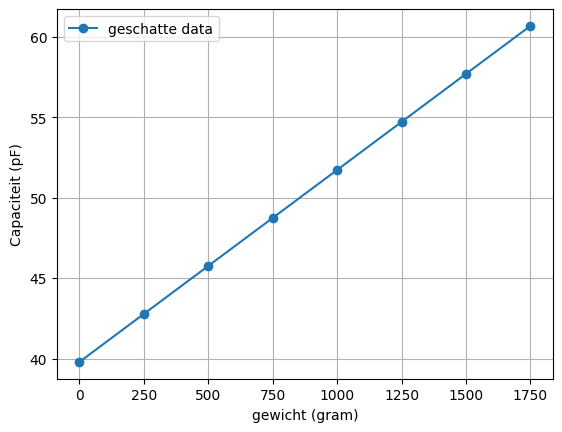

In [9]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

R=1000 #ohm. Dit is de Shunt-weerstand. 

def capaciteit(V): #Wij berekenen de capaciteit door middel van de formule V=IR+1/C*dV/dt. We hebben deze formule omgezet naar C=V/(R*1.6e6*np.pi). 
    return V/(R*1.6e6*np.pi) 


#data
gewicht  = np.array([0,250,500,750,
                 1000,1250,1500,1750]) # in gram

Volt = np.array([0.2,0.215,0.230,0.245,0.260,0.275,0.290,0.305]) #afgemeten voltage van de scope

Capaciteit = capaciteit(Volt)*1e12 #omzetten naar pF

#max en min capaciteit
mincapaciteit = capaciteit(0.200)
print("mincapaciteit is", mincapaciteit*1e12, "pF")
maxcapaciteit = capaciteit(0.280)
print("maxcapaciteit is", maxcapaciteit*1e12, "pF")

#plotten
plt.plot(gewicht,Capaciteit, label="geschatte data", marker="o") 
plt.xlabel("gewicht (gram)")
plt.ylabel("Capaciteit (pF)")
plt.legend() 
plt.grid() 


## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 39.8 |200 mV |
| gemiddelde capaciteit| 47.7 |239 mV |
| maximale capaciteit| 55.7 |280 mV |

## Opdracht 7: Plot de kalibratiegrafiek.

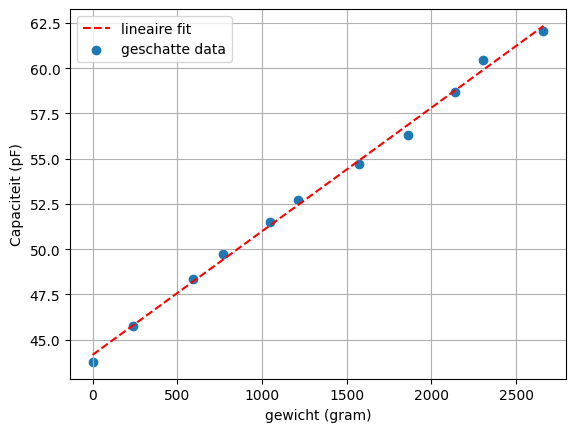

In [10]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

#zakjes gevuld met grind voor gewicht
g1 = 240.1 #gram 
g2 = 353.2 #gram
g3 = 174.8 #gram
g4 = 281.6 #gram
g5 = 161.0 #gram
g6 = 359.3 #gram
g7 = 289.2 #gram
g8 = 281.6 #gram
g9 = 161.0 #gram
g10 = 359.3 #gram


R=1000 #ohm. Dit is de Shunt-weerstand. 

def capaciteit(V): #Wij berekenen de capaciteit door middel van de formule V=IR+1/C*dV/dt. We hebben deze formule omgezet naar C=V/(R*1.6e6*np.pi). 
    return V/(R*1.6e6*np.pi) 


#data
gewicht  = np.array([0, g1, g1+g2, g1+g2+g3, g1+g2+g3+g4, g1+g2+g3+g4+g5, g1+g2+g3+g4+g5+g6, g1+g2+g3+g4+g5+g6+g7, g1+g2+g3+g4+g5+g6+g7+g8, g1+g2+g3+g4+g5+g6+g7+g8+g9, g1+g2+g3+g4+g5+g6+g7+g8+g9+g10]) # in gram

Volt = np.array([220,230,243,250,259,265,275,283,295,304,312])/1000 #afgemeten voltage van de scope

Capaciteit = capaciteit(Volt)*1e12 #omzetten naar pF

def lineair(x, a, b):
    return a * x + b

params, covariance = curve_fit(lineair, gewicht, Capaciteit)


xfit = np.linspace(np.min(gewicht), np.max(gewicht), 100)
yfit = lineair(xfit, *params)

#plotten
plt.plot(xfit, yfit, label="lineaire fit", color="red", linestyle="--")
plt.scatter(gewicht,Capaciteit, label="geschatte data", marker="o") 
plt.xlabel("gewicht (gram)")
plt.ylabel("Capaciteit (pF)")
plt.legend() 
plt.grid() 



## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
!<img src="Eindopstelling.jpeg" alt="schets student 1" width="400"/>

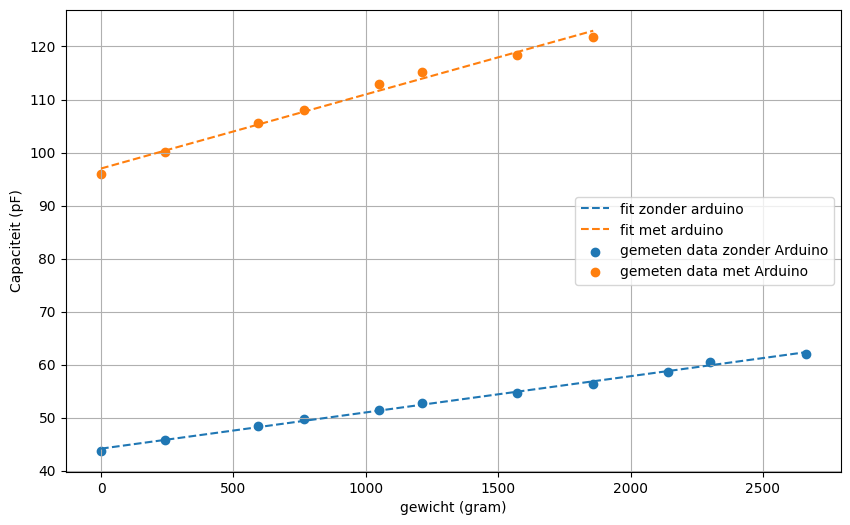

In [11]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

g1 = 240.1 #gram 
g2 = 353.2 #gram
g3 = 174.8 #gram    
g4 = 281.6 #gram
g5 = 161.0 #gram
g6 = 359.3 #gram
g7 = 289.2 #gram


R=1000 #ohm. Dit is de Shunt-weerstand. 

def capaciteit(V): #Wij berekenen de capaciteit door middel van de formule V=IR+1/C*dV/dt. We hebben deze formule omgezet naar C=V/(R*1.6e6*np.pi). 
    return V/(R*1.6e6*np.pi) 


#data
gewicht_arduino  = np.array([0, g1, g1+g2, g1+g2+g3, g1+g2+g3+g4, g1+g2+g3+g4+g5, g1+g2+g3+g4+g5+g6, g1+g2+g3+g4+g5+g6+g7]) # in gram

capaciteit_arduino = np.array([95.9, 100.1, 105.6, 108, 113, 115.1, 118.4, 121.7]) #afgemeten voltage van de scope

def lineair_arduino(x, a, b):
    return a * x + b

params_arduino, covariance_arduino = curve_fit(lineair_arduino, gewicht_arduino, capaciteit_arduino)

xfit_arduino = np.linspace(np.min(gewicht_arduino), np.max(gewicht_arduino), 100)
yfit_arduino = lineair_arduino(xfit_arduino, *params_arduino)


#plotten
plt.figure(figsize=(10,6))
plt.plot(xfit, yfit, label="fit zonder arduino", linestyle="--")
plt.plot(xfit_arduino, yfit_arduino, label="fit met arduino", linestyle="--")
plt.scatter(gewicht, Capaciteit, label="gemeten data zonder Arduino", marker="o") 
plt.scatter(gewicht_arduino,capaciteit_arduino, label="gemeten data met Arduino", marker="o") 
plt.xlabel("gewicht (gram)")
plt.ylabel("Capaciteit (pF)")
plt.legend() 
plt.grid() 

